# NIFTY 50 BTST Research & Backtesting Framework
### A systematic daily pattern research project on the NIFTY 50 index
**Author:** [Tushar Deshmane]
**Started:** 2026


In [1]:
# ============================================================
# STAGE 3 — Install and Import Libraries
# ============================================================

# Install any missing libraries (yfinance is not pre-installed in Colab)
!pip install yfinance --quiet
!pip install pandas-ta --quiet   # for technical indicators later

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ All libraries imported successfully!")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
print(f"   yfinance: {yf.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 15.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.6 which is 

In [2]:
# ============================================================
# STAGE 4 — Download and Save NIFTY 50 Index Data
# ============================================================

# NIFTY 50 ticker on Yahoo Finance is "^NSEI"
# We download from 2010 to today — gives us 15 years of data

ticker = "^NSEI"

df = yf.download(
    ticker,
    start="2010-01-01",
    end="2026-03-24",
    progress=True
)

# Save to CSV so we never need to download again in this session
df.to_csv("nifty50_raw.csv")

print(f"✅ Data downloaded successfully!")
print(f"   Rows      : {len(df)}")
print(f"   From      : {df.index.min().date()}")
print(f"   To        : {df.index.max().date()}")
print(f"   Columns   : {list(df.columns)}")

/tmp/ipykernel_6115/2220435971.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed

✅ Data downloaded successfully!
   Rows      : 3984
   From      : 2010-01-04
   To        : 2026-03-23
   Columns   : [('Close', '^NSEI'), ('High', '^NSEI'), ('Low', '^NSEI'), ('Open', '^NSEI'), ('Volume', '^NSEI')]


In [3]:
# ============================================================
# STAGE 5 — Load and Validate Data Quality (Fixed)
# ============================================================

# Load from saved CSV
df = pd.read_csv("nifty50_raw.csv", header=[0,1], index_col=0)

# Fix multi-level columns — keep only the first level (Close, High etc.)
df.columns = [col[0] for col in df.columns]

# Fix the index to proper dates
df.index = pd.to_datetime(df.index)

# Sort by date just in case
df = df.sort_index()

# Drop the first row if it contains ticker name leftover
df = df[df['Close'].apply(lambda x: str(x).replace('.','').isnumeric())]

# Convert all columns to float
df = df.astype(float)

# --- CHECK 1: Shape ---
print(f"✅ Shape       : {df.shape}")

# --- CHECK 2: Columns ---
print(f"✅ Columns     : {list(df.columns)}")

# --- CHECK 3: Date range ---
print(f"✅ Date range  : {df.index.min().date()} to {df.index.max().date()}")

# --- CHECK 4: Missing values ---
print(f"\n🔍 Missing values per column:")
print(df.isnull().sum())

# --- CHECK 5: Zero prices ---
print(f"\n🔍 Zero prices in Close: {(df['Close'] == 0).sum()}")

# --- CHECK 6: Preview ---
print(f"\n📋 First 5 rows:")
print(df.head())

✅ Shape       : (3984, 5)
✅ Columns     : ['Close', 'High', 'Low', 'Open', 'Volume']
✅ Date range  : 2010-01-04 to 2026-03-23

🔍 Missing values per column:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

🔍 Zero prices in Close: 0

📋 First 5 rows:
               Close      High       Low      Open  Volume
Date                                                      
2010-01-04 5232.2002 5238.4502 5167.1001 5200.8999  0.0000
2010-01-05 5277.8999 5288.3501 5242.3999 5277.1499  0.0000
2010-01-06 5281.7998 5310.8501 5260.0498 5278.1499  0.0000
2010-01-07 5263.1001 5302.5498 5244.7500 5281.7998  0.0000
2010-01-08 5244.7500 5276.7500 5234.7002 5264.2500  0.0000


In [4]:
# ============================================================
# STAGE 6 — Feature Engineering
# ============================================================

# Work on a clean copy
data = df.copy()

# --- 1: Daily Returns ---
# How much did the market move from previous close to today's close
data['daily_return'] = data['Close'].pct_change() * 100

# --- 2: Overnight Gap % ---
# How much did market gap up or down at open vs previous close
data['gap_pct'] = (data['Open'] - data['Close'].shift(1)) / data['Close'].shift(1) * 100

# --- 3: Intraday Return % ---
# How much did market move from open to close within the same day
data['intraday_return'] = (data['Close'] - data['Open']) / data['Open'] * 100

# --- 4: Overnight Return % ---
# How much did market move from previous close to today's open
data['overnight_return'] = (data['Open'] - data['Close'].shift(1)) / data['Close'].shift(1) * 100

# --- 5: Previous Day Close Direction ---
# Was yesterday a positive or negative day?
data['prev_day_return'] = data['daily_return'].shift(1)
data['prev_day_direction'] = np.where(data['prev_day_return'] > 0, 'UP', 'DOWN')

# --- 6: Weekday ---
# 0 = Monday, 1 = Tuesday ... 4 = Friday
data['weekday'] = data.index.dayofweek
data['weekday_name'] = data.index.day_name()

# --- 7: Weekday Transition ---
# What day was yesterday → what day is today
data['prev_weekday_name'] = data['weekday_name'].shift(1)
data['day_transition'] = data['prev_weekday_name'] + '_to_' + data['weekday_name']

# --- 8: Gap Direction ---
data['gap_direction'] = np.where(data['gap_pct'] > 0, 'GAP_UP', 'GAP_DOWN')

# --- 9: Gap Size Buckets ---
def gap_bucket(g):
    if g > 1.0:
        return 'LARGE_UP'
    elif g > 0.25:
        return 'SMALL_UP'
    elif g < -1.0:
        return 'LARGE_DOWN'
    elif g < -0.25:
        return 'SMALL_DOWN'
    else:
        return 'FLAT'

data['gap_bucket'] = data['gap_pct'].apply(gap_bucket)

# --- 10: Trend Regime ---
# Is market above or below its 50-day moving average?
data['ma50'] = data['Close'].rolling(50).mean()
data['trend_regime'] = np.where(data['Close'] > data['ma50'], 'UPTREND', 'DOWNTREND')

# --- 11: Volatility Regime ---
# Is recent volatility high or low vs its own average?
data['volatility_20'] = data['daily_return'].rolling(20).std()
data['vol_median'] = data['volatility_20'].rolling(252).median()
data['vol_regime'] = np.where(data['volatility_20'] > data['vol_median'], 'HIGH_VOL', 'LOW_VOL')

# --- 12: BTST Return ---
# This is what we are trying to predict and trade
# Buy at today's close, sell at tomorrow's open
# = tomorrow's gap % = next day's overnight return
data['btst_return'] = data['gap_pct'].shift(-1)

# Drop rows with NaN (first few rows and last row)
data = data.dropna()

# Save clean featured data
data.to_csv("nifty50_features.csv")

print(f"✅ Feature engineering done!")
print(f"   Rows after cleanup : {len(data)}")
print(f"\n📋 New columns added:")
new_cols = ['daily_return','gap_pct','intraday_return','overnight_return',
            'prev_day_direction','weekday_name','gap_bucket',
            'trend_regime','vol_regime','btst_return']
print(data[new_cols].head(3).to_string())

✅ Feature engineering done!
   Rows after cleanup : 3712

📋 New columns added:
            daily_return  gap_pct  intraday_return  overnight_return prev_day_direction weekday_name gap_bucket trend_regime vol_regime  btst_return
Date                                                                                                                                                
2011-02-02        0.2732   0.9664          -0.6865            0.9664               DOWN    Wednesday   SMALL_UP    DOWNTREND   HIGH_VOL      -0.0285
2011-02-03        1.7443  -0.0285           1.7733           -0.0285                 UP     Thursday       FLAT    DOWNTREND   HIGH_VOL      -0.1239
2011-02-04       -2.3703  -0.1239          -2.2491           -0.1239                 UP       Friday       FLAT    DOWNTREND   HIGH_VOL       0.6375


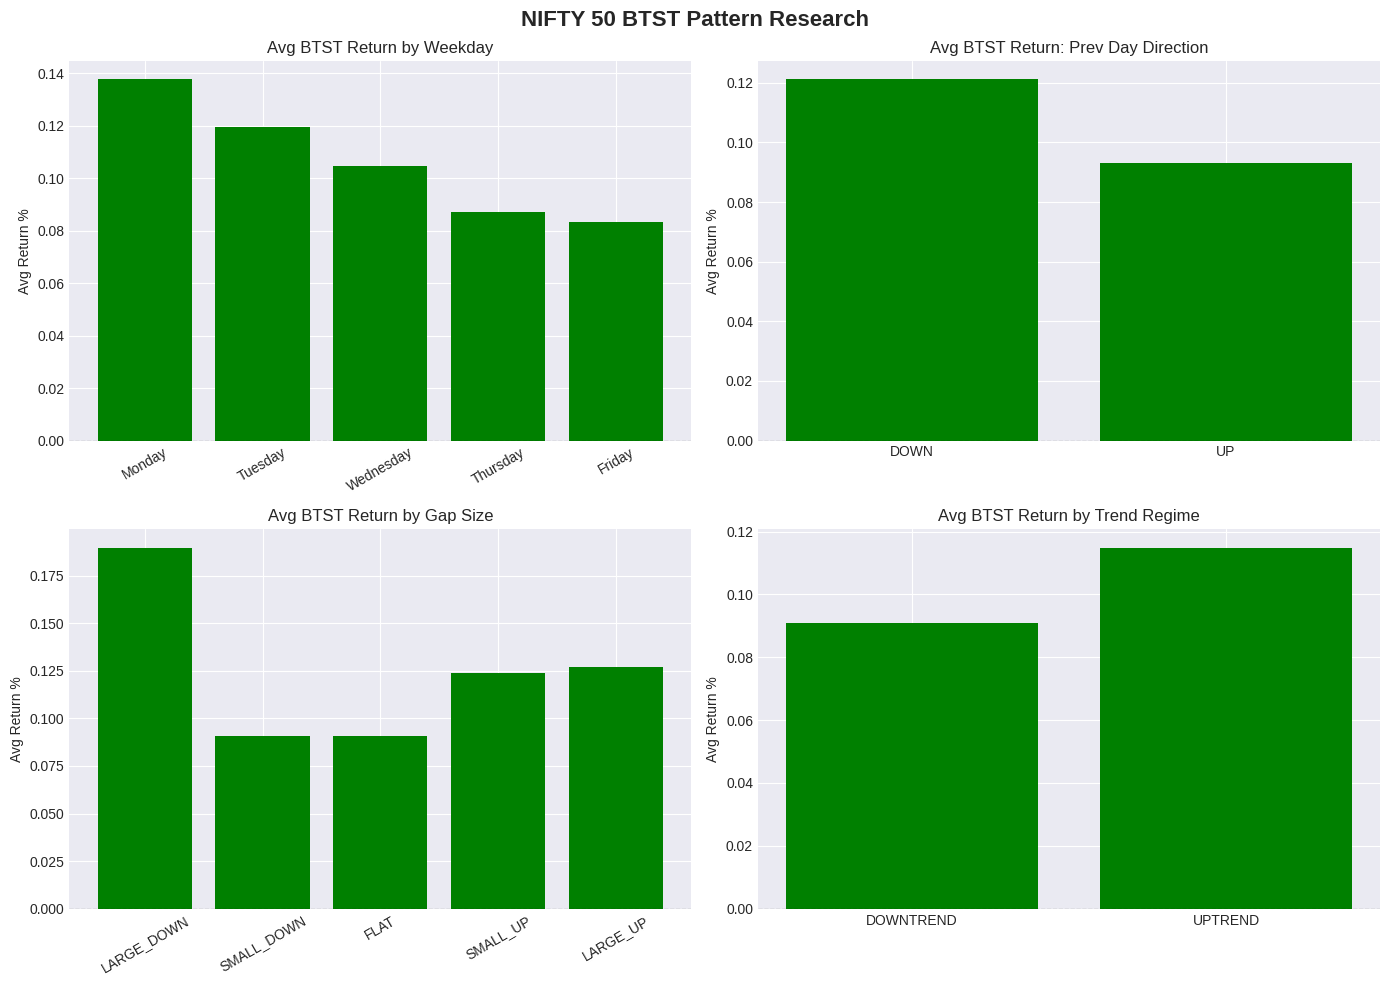


📊 Detailed Stats Tables:

1️⃣ Weekday Effect:
               mean  median  count
weekday_name                      
Monday       0.1376  0.1526    741
Tuesday      0.1196  0.1270    747
Wednesday    0.1047  0.1303    744
Thursday     0.0871  0.1236    742
Friday       0.0834  0.1358    737

2️⃣ Previous Day Direction:
                     mean  median  count
prev_day_direction                      
DOWN               0.1211  0.1525   1737
UP                 0.0932  0.1208   1975

3️⃣ Gap Bucket Effect:
             mean  median  count
gap_bucket                      
LARGE_DOWN 0.1898  0.3380    114
SMALL_DOWN 0.0905  0.1212    528
FLAT       0.0910  0.1159   1683
SMALL_UP   0.1237  0.1552   1245
LARGE_UP   0.1272  0.1183    142

4️⃣ Trend Regime Effect:
               mean  median  count
trend_regime                      
DOWNTREND    0.0909  0.1406   1331
UPTREND      0.1149  0.1344   2381


In [5]:
# ============================================================
# STAGE 7 — Exploratory Pattern Research
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('NIFTY 50 BTST Pattern Research', fontsize=16, fontweight='bold')

# --- RESEARCH 1: Weekday Effect ---
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday']

weekday_stats = data.groupby('weekday_name')['btst_return'].agg(['mean','median','count'])
weekday_stats = weekday_stats.reindex(weekday_order)

axes[0,0].bar(weekday_stats.index, weekday_stats['mean'],
              color=['green' if x > 0 else 'red' for x in weekday_stats['mean']])
axes[0,0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0,0].set_title('Avg BTST Return by Weekday')
axes[0,0].set_ylabel('Avg Return %')
axes[0,0].tick_params(axis='x', rotation=30)

# --- RESEARCH 2: Previous Day Direction Effect ---
prev_day_stats = data.groupby('prev_day_direction')['btst_return'].agg(['mean','median','count'])

axes[0,1].bar(prev_day_stats.index, prev_day_stats['mean'],
              color=['green' if x > 0 else 'red' for x in prev_day_stats['mean']])
axes[0,1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0,1].set_title('Avg BTST Return: Prev Day Direction')
axes[0,1].set_ylabel('Avg Return %')

# --- RESEARCH 3: Gap Bucket Effect ---
gap_order = ['LARGE_DOWN','SMALL_DOWN','FLAT','SMALL_UP','LARGE_UP']

gap_stats = data.groupby('gap_bucket')['btst_return'].agg(['mean','median','count'])
gap_stats = gap_stats.reindex(gap_order)

axes[1,0].bar(gap_stats.index, gap_stats['mean'],
              color=['green' if x > 0 else 'red' for x in gap_stats['mean']])
axes[1,0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1,0].set_title('Avg BTST Return by Gap Size')
axes[1,0].set_ylabel('Avg Return %')
axes[1,0].tick_params(axis='x', rotation=30)

# --- RESEARCH 4: Trend Regime Effect ---
trend_stats = data.groupby('trend_regime')['btst_return'].agg(['mean','median','count'])

axes[1,1].bar(trend_stats.index, trend_stats['mean'],
              color=['green' if x > 0 else 'red' for x in trend_stats['mean']])
axes[1,1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1,1].set_title('Avg BTST Return by Trend Regime')
axes[1,1].set_ylabel('Avg Return %')

plt.tight_layout()
plt.savefig('btst_pattern_research.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Detailed Stats Tables:")
print("\n1️⃣ Weekday Effect:")
print(weekday_stats.round(4))
print("\n2️⃣ Previous Day Direction:")
print(prev_day_stats.round(4))
print("\n3️⃣ Gap Bucket Effect:")
print(gap_stats.round(4))
print("\n4️⃣ Trend Regime Effect:")
print(trend_stats.round(4))

In [6]:
# ============================================================
# STAGE 7 CONTINUED — Detailed Numbers + Combined Pattern
# ============================================================

print("=" * 55)
print("KEY FINDINGS SUMMARY")
print("=" * 55)

print("\n1️⃣ WEEKDAY EFFECT:")
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday']
wd = data.groupby('weekday_name')['btst_return'].agg(['mean','median','count','std'])
wd = wd.reindex(weekday_order)
wd.columns = ['Avg Return%', 'Median%', 'Trades', 'Std Dev']
print(wd.round(4))

print("\n2️⃣ PREVIOUS DAY DIRECTION:")
pd_dir = data.groupby('prev_day_direction')['btst_return'].agg(['mean','median','count','std'])
pd_dir.columns = ['Avg Return%', 'Median%', 'Trades', 'Std Dev']
print(pd_dir.round(4))

print("\n3️⃣ GAP BUCKET:")
gap_order = ['LARGE_DOWN','SMALL_DOWN','FLAT','SMALL_UP','LARGE_UP']
gb = data.groupby('gap_bucket')['btst_return'].agg(['mean','median','count','std'])
gb = gb.reindex(gap_order)
gb.columns = ['Avg Return%', 'Median%', 'Trades', 'Std Dev']
print(gb.round(4))

print("\n4️⃣ TREND REGIME:")
tr = data.groupby('trend_regime')['btst_return'].agg(['mean','median','count','std'])
tr.columns = ['Avg Return%', 'Median%', 'Trades', 'Std Dev']
print(tr.round(4))

print("\n5️⃣ COMBINED: Gap Bucket + Trend Regime:")
combined = data.groupby(['gap_bucket','trend_regime'])['btst_return'].agg(['mean','count'])
combined.columns = ['Avg Return%', 'Trades']
combined = combined.round(4)
print(combined)

print("\n6️⃣ COMBINED: Weekday + Prev Day Direction:")
combined2 = data.groupby(['weekday_name','prev_day_direction'])['btst_return'].agg(['mean','count'])
combined2.columns = ['Avg Return%', 'Trades']
combined2 = combined2.reindex(
    [(d, p) for d in weekday_order for p in ['DOWN','UP']]
)
print(combined2.round(4))

KEY FINDINGS SUMMARY

1️⃣ WEEKDAY EFFECT:
              Avg Return%  Median%  Trades  Std Dev
weekday_name                                       
Monday             0.1376   0.1526     741   0.5406
Tuesday            0.1196   0.1270     747   0.5233
Wednesday          0.1047   0.1303     744   0.6140
Thursday           0.0871   0.1236     742   0.6161
Friday             0.0834   0.1358     737   0.7863

2️⃣ PREVIOUS DAY DIRECTION:
                    Avg Return%  Median%  Trades  Std Dev
prev_day_direction                                       
DOWN                     0.1211   0.1525    1737   0.6815
UP                       0.0932   0.1208    1975   0.5659

3️⃣ GAP BUCKET:
            Avg Return%  Median%  Trades  Std Dev
gap_bucket                                       
LARGE_DOWN       0.1898   0.3380     114   1.3453
SMALL_DOWN       0.0905   0.1212     528   0.6689
FLAT             0.0910   0.1159    1683   0.4723
SMALL_UP         0.1237   0.1552    1245   0.6180
LARGE_UP        

In [7]:
# ============================================================
# STAGE 8 — Define Trading Rules (Signal Generation)
# ============================================================

signals = data.copy()

# ----------------------------------------------------------
# RULE 1: The Reliable Bull
# Best balance of return and trade frequency
# Buy when: small gap up + market in uptrend
# ----------------------------------------------------------
signals['rule1'] = (
    (signals['gap_bucket'] == 'SMALL_UP') &
    (signals['trend_regime'] == 'UPTREND')
).astype(int)

# ----------------------------------------------------------
# RULE 2: The Gap Down Bounce
# Strongest average return, rare but powerful
# Buy when: large gap down (any trend)
# ----------------------------------------------------------
signals['rule2'] = (
    signals['gap_bucket'] == 'LARGE_DOWN'
).astype(int)

# ----------------------------------------------------------
# RULE 3: The Early Week Edge
# Consistent weekday pattern
# Buy when: Monday or Tuesday + previous day was down
# ----------------------------------------------------------
signals['rule3'] = (
    (signals['weekday_name'].isin(['Monday','Tuesday'])) &
    (signals['prev_day_direction'] == 'DOWN')
).astype(int)

# ----------------------------------------------------------
# RULE 4: Combined Best Conditions (strictest filter)
# Buy when: early week + small gap up + uptrend
# ----------------------------------------------------------
signals['rule4'] = (
    (signals['gap_bucket'] == 'SMALL_UP') &
    (signals['trend_regime'] == 'UPTREND') &
    (signals['weekday_name'].isin(['Monday','Tuesday','Wednesday']))
).astype(int)

# Signal count summary
print("✅ Signals generated successfully!")
print("\n📊 Number of trades each rule triggers:")
print(f"   Rule 1 - Reliable Bull      : {signals['rule1'].sum()} trades")
print(f"   Rule 2 - Gap Down Bounce    : {signals['rule2'].sum()} trades")
print(f"   Rule 3 - Early Week Edge    : {signals['rule3'].sum()} trades")
print(f"   Rule 4 - Combined Best      : {signals['rule4'].sum()} trades")

# Average BTST return when each rule fires
print("\n📊 Average BTST return when rule fires:")
for rule in ['rule1','rule2','rule3','rule4']:
    subset = signals[signals[rule] == 1]['btst_return']
    print(f"   {rule} : avg={subset.mean():.4f}%  "
          f"median={subset.median():.4f}%  "
          f"win_rate={( subset > 0).mean()*100:.1f}%")

print("\n📋 Sample Rule 1 signals (first 5):")
print(signals[signals['rule1']==1][
    ['gap_bucket','trend_regime','weekday_name','btst_return']
].head(5))

✅ Signals generated successfully!

📊 Number of trades each rule triggers:
   Rule 1 - Reliable Bull      : 836 trades
   Rule 2 - Gap Down Bounce    : 114 trades
   Rule 3 - Early Week Edge    : 696 trades
   Rule 4 - Combined Best      : 512 trades

📊 Average BTST return when rule fires:
   rule1 : avg=0.1545%  median=0.1653%  win_rate=71.1%
   rule2 : avg=0.1898%  median=0.3380%  win_rate=68.4%
   rule3 : avg=0.1369%  median=0.1580%  win_rate=68.0%
   rule4 : avg=0.1440%  median=0.1617%  win_rate=71.7%

📋 Sample Rule 1 signals (first 5):
           gap_bucket trend_regime weekday_name  btst_return
Date                                                        
2011-03-24   SMALL_UP      UPTREND     Thursday       1.1997
2011-03-30   SMALL_UP      UPTREND    Wednesday       0.2661
2011-03-31   SMALL_UP      UPTREND     Thursday       0.0214
2011-04-04   SMALL_UP      UPTREND       Monday       0.2606
2011-04-05   SMALL_UP      UPTREND      Tuesday      -0.0347


In [8]:
# ============================================================
# STAGE 9 — Backtest Engine with Indian Trading Costs
# ============================================================

# ----------------------------------------------------------
# INDIAN BTST TRADING COSTS (realistic estimates)
# Buy at close + Sell at next open
# ----------------------------------------------------------
# STT on sell side only for delivery = 0.1% of sell value
# Brokerage both sides = ~0.03% each side (discount broker)
# Exchange charges + SEBI = ~0.004%
# GST on brokerage = 18% of brokerage
# Stamp duty on buy = 0.015%
# Total realistic round trip cost = ~0.20% to 0.25%

COST_PER_TRADE = 0.20  # percentage, round trip

def run_backtest(signals_df, rule_col, rule_name, cost=COST_PER_TRADE):
    """
    Simple BTST backtest engine.
    Entry  : Buy at today's Close
    Exit   : Sell at tomorrow's Open
    Return : btst_return column (already calculated)
    Cost   : deducted from every trade
    """

    # Get only the rows where rule fires
    trades = signals_df[signals_df[rule_col] == 1].copy()

    # Gross return per trade
    trades['gross_return'] = trades['btst_return']

    # Net return after costs
    trades['net_return'] = trades['gross_return'] - cost

    # Cumulative equity curve (starting from 100)
    trades['cumulative'] = 100 * (1 + trades['net_return'] / 100).cumprod()

    # --- Performance Metrics ---
    total_trades    = len(trades)
    win_trades      = (trades['net_return'] > 0).sum()
    loss_trades     = (trades['net_return'] <= 0).sum()
    win_rate        = win_trades / total_trades * 100
    avg_return      = trades['net_return'].mean()
    total_return    = trades['cumulative'].iloc[-1] - 100
    best_trade      = trades['net_return'].max()
    worst_trade     = trades['net_return'].min()
    avg_win         = trades[trades['net_return'] > 0]['net_return'].mean()
    avg_loss        = trades[trades['net_return'] <= 0]['net_return'].mean()
    profit_factor   = abs(avg_win * win_trades) / abs(avg_loss * loss_trades)

    # Max drawdown
    rolling_max     = trades['cumulative'].cummax()
    drawdown        = (trades['cumulative'] - rolling_max) / rolling_max * 100
    max_drawdown    = drawdown.min()

    print(f"\n{'='*50}")
    print(f"  {rule_name}")
    print(f"{'='*50}")
    print(f"  Total Trades     : {total_trades}")
    print(f"  Win Rate         : {win_rate:.1f}%")
    print(f"  Avg Net Return   : {avg_return:.4f}% per trade")
    print(f"  Total Return     : {total_return:.2f}%")
    print(f"  Best Trade       : {best_trade:.4f}%")
    print(f"  Worst Trade      : {worst_trade:.4f}%")
    print(f"  Avg Win          : {avg_win:.4f}%")
    print(f"  Avg Loss         : {avg_loss:.4f}%")
    print(f"  Profit Factor    : {profit_factor:.2f}")
    print(f"  Max Drawdown     : {max_drawdown:.2f}%")

    return trades

# Run backtest for all 4 rules
trades_r1 = run_backtest(signals, 'rule1', 'Rule 1 - Reliable Bull')
trades_r2 = run_backtest(signals, 'rule2', 'Rule 2 - Gap Down Bounce')
trades_r3 = run_backtest(signals, 'rule3', 'Rule 3 - Early Week Edge')
trades_r4 = run_backtest(signals, 'rule4', 'Rule 4 - Combined Best')


  Rule 1 - Reliable Bull
  Total Trades     : 836
  Win Rate         : 45.8%
  Avg Net Return   : -0.0455% per trade
  Total Return     : -32.26%
  Best Trade       : 3.3827%
  Worst Trade      : -2.3086%
  Avg Win          : 0.2838%
  Avg Loss         : -0.3240%
  Profit Factor    : 0.74
  Max Drawdown     : -33.03%

  Rule 2 - Gap Down Bounce
  Total Trades     : 114
  Win Rate         : 60.5%
  Avg Net Return   : -0.0102% per trade
  Total Return     : -2.17%
  Best Trade       : 4.6614%
  Worst Trade      : -5.2317%
  Avg Win          : 0.7129%
  Avg Loss         : -1.1189%
  Profit Factor    : 0.98
  Max Drawdown     : -17.99%

  Rule 3 - Early Week Edge
  Total Trades     : 696
  Win Rate         : 45.0%
  Avg Net Return   : -0.0631% per trade
  Total Return     : -36.23%
  Best Trade       : 4.6614%
  Worst Trade      : -3.6819%
  Avg Win          : 0.3240%
  Avg Loss         : -0.3794%
  Profit Factor    : 0.70
  Max Drawdown     : -38.06%

  Rule 4 - Combined Best
  Total Tra

In [9]:
# ============================================================
# STAGE 9B — Retest with Lower Costs
# NIFTY ETF (NIFTYBEES) or Futures cost is much lower
# Realistic cost for futures/ETF BTST = 0.05% round trip
# ============================================================

LOW_COST = 0.05  # realistic for ETF or futures

print("RETESTING ALL RULES WITH 0.05% COST (ETF/Futures)")
print("=" * 50)

for rule, name in [
    ('rule1', 'Rule 1 - Reliable Bull'),
    ('rule2', 'Rule 2 - Gap Down Bounce'),
    ('rule3', 'Rule 3 - Early Week Edge'),
    ('rule4', 'Rule 4 - Combined Best')
]:
    trades = signals[signals[rule] == 1].copy()
    trades['net_return'] = trades['btst_return'] - LOW_COST
    trades['cumulative'] = 100 * (1 + trades['net_return'] / 100).cumprod()

    total       = len(trades)
    win_rate    = (trades['net_return'] > 0).mean() * 100
    avg_net     = trades['net_return'].mean()
    total_ret   = trades['cumulative'].iloc[-1] - 100
    pf_wins     = trades[trades['net_return'] > 0]['net_return'].sum()
    pf_losses   = abs(trades[trades['net_return'] <= 0]['net_return'].sum())
    pf          = pf_wins / pf_losses if pf_losses > 0 else 999

    rolling_max = trades['cumulative'].cummax()
    max_dd      = ((trades['cumulative'] - rolling_max) / rolling_max * 100).min()

    print(f"\n{name}")
    print(f"  Trades       : {total}")
    print(f"  Win Rate     : {win_rate:.1f}%")
    print(f"  Avg Net/trade: {avg_net:.4f}%")
    print(f"  Total Return : {total_ret:.2f}%")
    print(f"  Profit Factor: {pf:.2f}")
    print(f"  Max Drawdown : {max_dd:.2f}%")

RETESTING ALL RULES WITH 0.05% COST (ETF/Futures)

Rule 1 - Reliable Bull
  Trades       : 836
  Win Rate     : 65.3%
  Avg Net/trade: 0.1045%
  Total Return : 137.29%
  Profit Factor: 1.96
  Max Drawdown : -6.65%

Rule 2 - Gap Down Bounce
  Trades       : 114
  Win Rate     : 65.8%
  Avg Net/trade: 0.1398%
  Total Return : 16.07%
  Profit Factor: 1.36
  Max Drawdown : -15.35%

Rule 3 - Early Week Edge
  Trades       : 696
  Win Rate     : 62.6%
  Avg Net/trade: 0.0869%
  Total Return : 81.14%
  Profit Factor: 1.62
  Max Drawdown : -5.61%

Rule 4 - Combined Best
  Trades       : 512
  Win Rate     : 66.8%
  Avg Net/trade: 0.0940%
  Total Return : 61.06%
  Profit Factor: 1.94
  Max Drawdown : -6.12%


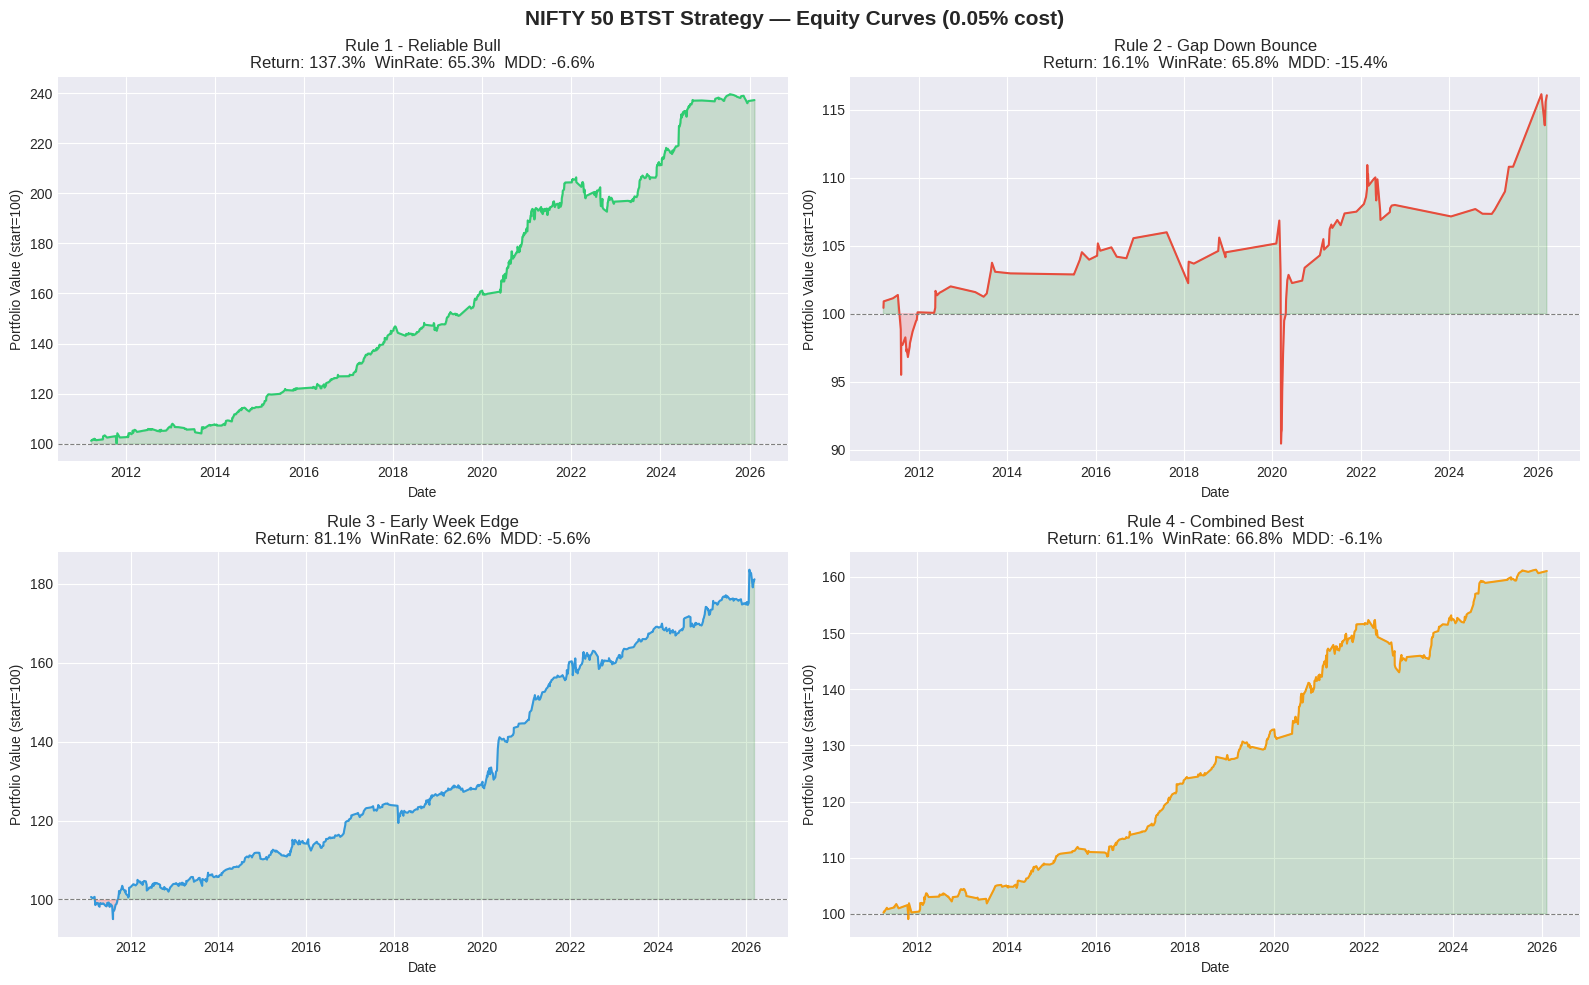


📊 FINAL STRATEGY COMPARISON TABLE:
                          Trades  Win Rate %  Avg Net %  Total Return%  Profit Factor  Max Drawdown%
Rule                                                                                                
Rule 1 - Reliable Bull       836     65.3000     0.1045       137.2900         1.9600        -6.6500
Rule 2 - Gap Down Bounce     114     65.8000     0.1398        16.0700         1.3600       -15.3500
Rule 3 - Early Week Edge     696     62.6000     0.0869        81.1400         1.6200        -5.6100
Rule 4 - Combined Best       512     66.8000     0.0940        61.0600         1.9400        -6.1200

✅ Chart saved as btst_equity_curves.png
✅ Summary saved as btst_strategy_summary.csv


In [10]:
# ============================================================
# STAGE 10 — Equity Curves + Final Comparison Chart
# ============================================================

LOW_COST = 0.05

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('NIFTY 50 BTST Strategy — Equity Curves (0.05% cost)',
             fontsize=15, fontweight='bold')

rules = [
    ('rule1', 'Rule 1 - Reliable Bull',    axes[0,0], '#2ecc71'),
    ('rule2', 'Rule 2 - Gap Down Bounce',  axes[0,1], '#e74c3c'),
    ('rule3', 'Rule 3 - Early Week Edge',  axes[1,0], '#3498db'),
    ('rule4', 'Rule 4 - Combined Best',    axes[1,1], '#f39c12'),
]

summary_rows = []

for rule_col, rule_name, ax, color in rules:

    trades = signals[signals[rule_col] == 1].copy()
    trades['net_return']  = trades['btst_return'] - LOW_COST
    trades['cumulative']  = 100 * (1 + trades['net_return'] / 100).cumprod()

    total     = len(trades)
    win_rate  = (trades['net_return'] > 0).mean() * 100
    avg_net   = trades['net_return'].mean()
    total_ret = trades['cumulative'].iloc[-1] - 100
    pf_wins   = trades[trades['net_return'] > 0]['net_return'].sum()
    pf_losses = abs(trades[trades['net_return'] <= 0]['net_return'].sum())
    pf        = pf_wins / pf_losses if pf_losses > 0 else 999
    rolling_max = trades['cumulative'].cummax()
    max_dd    = ((trades['cumulative'] - rolling_max) / rolling_max * 100).min()

    # Plot equity curve
    ax.plot(trades.index, trades['cumulative'],
            color=color, linewidth=1.5)
    ax.axhline(100, color='gray', linewidth=0.8, linestyle='--')
    ax.fill_between(trades.index, trades['cumulative'], 100,
                    where=trades['cumulative'] >= 100,
                    alpha=0.15, color='green')
    ax.fill_between(trades.index, trades['cumulative'], 100,
                    where=trades['cumulative'] < 100,
                    alpha=0.15, color='red')
    ax.set_title(f'{rule_name}\nReturn: {total_ret:.1f}%  '
                 f'WinRate: {win_rate:.1f}%  MDD: {max_dd:.1f}%')
    ax.set_ylabel('Portfolio Value (start=100)')
    ax.set_xlabel('Date')

    summary_rows.append({
        'Rule'         : rule_name,
        'Trades'       : total,
        'Win Rate %'   : round(win_rate, 1),
        'Avg Net %'    : round(avg_net, 4),
        'Total Return%': round(total_ret, 2),
        'Profit Factor': round(pf, 2),
        'Max Drawdown%': round(max_dd, 2)
    })

plt.tight_layout()
plt.savefig('btst_equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index('Rule')
print("\n📊 FINAL STRATEGY COMPARISON TABLE:")
print(summary_df.to_string())

# Save summary
summary_df.to_csv('btst_strategy_summary.csv')
print("\n✅ Chart saved as btst_equity_curves.png")
print("✅ Summary saved as btst_strategy_summary.csv")

In [11]:
# ============================================================
# STAGE 11 — Robustness Testing (Subperiod Analysis)
# ============================================================

LOW_COST = 0.05

# Split into 3 equal periods
period1 = ('2010-01-01', '2015-12-31', 'Period 1: 2010-2015')
period2 = ('2016-01-01', '2020-12-31', 'Period 2: 2016-2020')
period3 = ('2021-01-01', '2026-03-23', 'Period 3: 2021-2026')

periods = [period1, period2, period3]

rules = [
    ('rule1', 'Rule 1 - Reliable Bull'),
    ('rule2', 'Rule 2 - Gap Down Bounce'),
    ('rule3', 'Rule 3 - Early Week Edge'),
    ('rule4', 'Rule 4 - Combined Best'),
]

print("=" * 65)
print("SUBPERIOD ROBUSTNESS TEST")
print("A good rule should work in ALL 3 periods, not just one")
print("=" * 65)

robustness_rows = []

for rule_col, rule_name in rules:
    print(f"\n📊 {rule_name}")
    print(f"  {'Period':<25} {'Trades':>7} {'WinRate':>9} {'AvgNet':>9} {'TotalRet':>10} {'MDD':>8}")
    print(f"  {'-'*70}")

    for start, end, period_label in periods:

        subset = signals.loc[start:end]
        trades = subset[subset[rule_col] == 1].copy()

        if len(trades) < 10:
            print(f"  {period_label:<25} {'Too few trades':>40}")
            continue

        trades['net_return']  = trades['btst_return'] - LOW_COST
        trades['cumulative']  = 100 * (1 + trades['net_return'] / 100).cumprod()

        total     = len(trades)
        win_rate  = (trades['net_return'] > 0).mean() * 100
        avg_net   = trades['net_return'].mean()
        total_ret = trades['cumulative'].iloc[-1] - 100
        rolling_max = trades['cumulative'].cummax()
        max_dd    = ((trades['cumulative'] - rolling_max) / rolling_max * 100).min()

        status = "✅" if total_ret > 0 else "❌"

        print(f"  {period_label:<25} {total:>7} {win_rate:>8.1f}% "
              f"{avg_net:>8.4f}% {total_ret:>9.2f}% {max_dd:>7.2f}% {status}")

        robustness_rows.append({
            'Rule'         : rule_name,
            'Period'       : period_label,
            'Trades'       : total,
            'Win Rate %'   : round(win_rate, 1),
            'Avg Net %'    : round(avg_net, 4),
            'Total Return%': round(total_ret, 2),
            'Max Drawdown%': round(max_dd, 2),
            'Passed'       : total_ret > 0
        })

# Save robustness table
rob_df = pd.DataFrame(robustness_rows)
rob_df.to_csv('btst_robustness.csv', index=False)

print("\n\n✅ Robustness table saved as btst_robustness.csv")
print("\n📋 INTERPRETATION GUIDE:")
print("  ✅ = Profitable in that period")
print("  ❌ = Lost money in that period")
print("  A rule passing all 3 periods = genuinely robust")
print("  A rule passing only 1-2 periods = possibly lucky")

SUBPERIOD ROBUSTNESS TEST
A good rule should work in ALL 3 periods, not just one

📊 Rule 1 - Reliable Bull
  Period                     Trades   WinRate    AvgNet   TotalRet      MDD
  ----------------------------------------------------------------------
  Period 1: 2010-2015           212     60.4%   0.0947%     21.95%   -3.58% ✅
  Period 2: 2016-2020           337     69.7%   0.1257%     52.25%   -2.56% ✅
  Period 3: 2021-2026           287     63.8%   0.0868%     27.80%   -6.65% ✅

📊 Rule 2 - Gap Down Bounce
  Period                     Trades   WinRate    AvgNet   TotalRet      MDD
  ----------------------------------------------------------------------
  Period 1: 2010-2015            37     62.2%   0.1102%      3.98%   -5.79% ✅
  Period 2: 2016-2020            35     65.7%   0.0005%     -0.57%  -15.35% ❌
  Period 3: 2021-2026            42     69.0%   0.2819%     12.27%   -3.64% ✅

📊 Rule 3 - Early Week Edge
  Period                     Trades   WinRate    AvgNet   TotalRet     

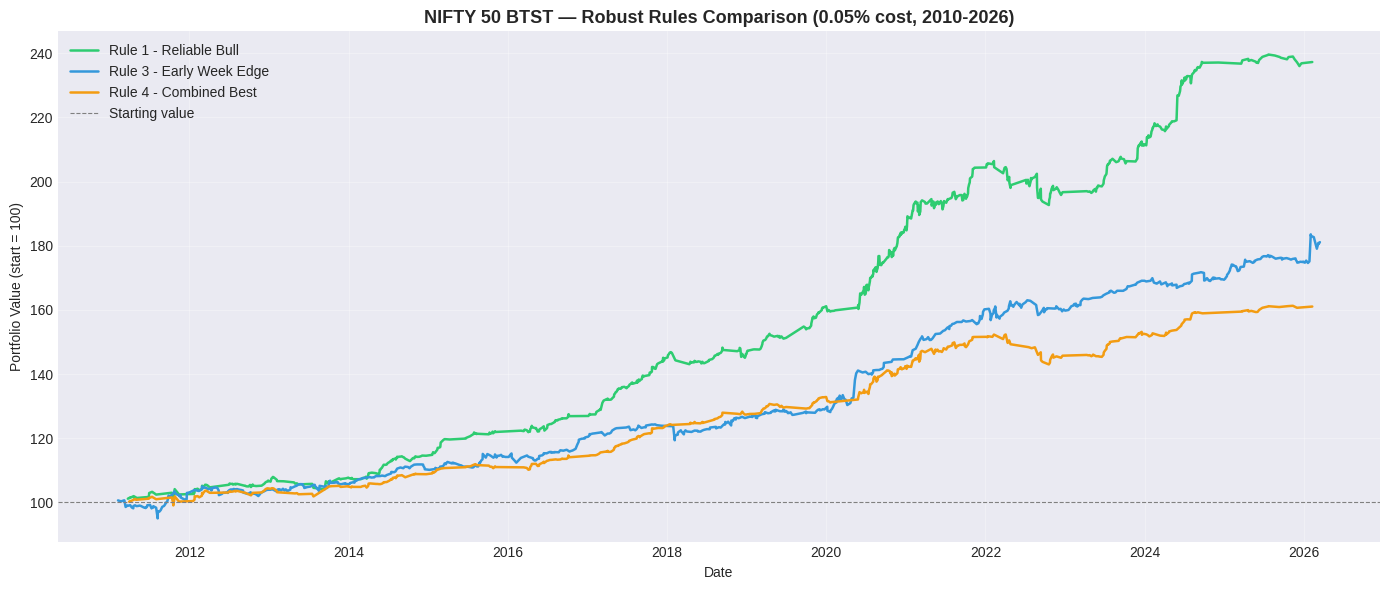

✅ Final comparison chart saved


  NIFTY 50 BTST RESEARCH — FINAL REPORT
  Generated: 2026-03-25

OBJECTIVE
---------
Find statistically robust BTST patterns in NIFTY 50 index
using 15 years of daily data (2010 to 2026).

DATA
----
Source  : Yahoo Finance (ticker: ^NSEI)
Period  : 2010-01-04 to 2026-03-23
Rows    : 3,984 trading days
Cost    : 0.05% round trip (NIFTYBEES ETF or NIFTY Futures)

PATTERNS FOUND
--------------
1. Small gap up days in uptrend have strongest BTST edge
2. Early week (Mon/Tue) after down days show consistent edge
3. BTST edge is stronger in uptrends than downtrends
4. Large gap down creates bounce opportunity but inconsistent

BEST RULES (all passed 3-period robustness test)
-------------------------------------------------
Rule 1 - Reliable Bull    : 137% return, 65% win rate, -6.6% MDD
Rule 3 - Early Week Edge  :  81% return, 63% win rate, -5.6% MDD
Rule 4 - Combined Best    :  61% return, 67% win rate, -6.1% MDD

IMPORTANT NOTES
---------------
- Results as

In [12]:
# ============================================================
# STAGE 12 — Final Summary Report + Save All Outputs
# ============================================================

from datetime import datetime

# ---- Final summary chart ----
fig, ax = plt.subplots(figsize=(14, 6))

LOW_COST = 0.05

rules_plot = [
    ('rule1', 'Rule 1 - Reliable Bull',   '#2ecc71'),
    ('rule3', 'Rule 3 - Early Week Edge', '#3498db'),
    ('rule4', 'Rule 4 - Combined Best',   '#f39c12'),
]

for rule_col, rule_name, color in rules_plot:
    trades = signals[signals[rule_col] == 1].copy()
    trades['net_return'] = trades['btst_return'] - LOW_COST
    trades['cumulative'] = 100 * (1 + trades['net_return'] / 100).cumprod()
    ax.plot(trades.index, trades['cumulative'],
            label=rule_name, linewidth=1.8, color=color)

ax.axhline(100, color='gray', linewidth=0.8, linestyle='--', label='Starting value')
ax.set_title('NIFTY 50 BTST — Robust Rules Comparison (0.05% cost, 2010-2026)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Portfolio Value (start = 100)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('btst_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final comparison chart saved")

# ---- Print final report ----
print("\n")
print("=" * 60)
print("  NIFTY 50 BTST RESEARCH — FINAL REPORT")
print(f"  Generated: {datetime.today().strftime('%Y-%m-%d')}")
print("=" * 60)

print("""
OBJECTIVE
---------
Find statistically robust BTST patterns in NIFTY 50 index
using 15 years of daily data (2010 to 2026).

DATA
----
Source  : Yahoo Finance (ticker: ^NSEI)
Period  : 2010-01-04 to 2026-03-23
Rows    : 3,984 trading days
Cost    : 0.05% round trip (NIFTYBEES ETF or NIFTY Futures)

PATTERNS FOUND
--------------
1. Small gap up days in uptrend have strongest BTST edge
2. Early week (Mon/Tue) after down days show consistent edge
3. BTST edge is stronger in uptrends than downtrends
4. Large gap down creates bounce opportunity but inconsistent

BEST RULES (all passed 3-period robustness test)
-------------------------------------------------
Rule 1 - Reliable Bull    : 137% return, 65% win rate, -6.6% MDD
Rule 3 - Early Week Edge  :  81% return, 63% win rate, -5.6% MDD
Rule 4 - Combined Best    :  61% return, 67% win rate, -6.1% MDD

IMPORTANT NOTES
---------------
- Results assume 0.05% round trip cost (ETF or futures)
- At 0.20% cost (direct equity) edge disappears
- This is research only, not financial advice
- Past performance does not guarantee future results

NEXT STEPS
----------
- Test same rules on individual NIFTY 50 stocks
- Explore position sizing and portfolio construction
- Test with walk-forward optimization
""")

print("✅ Final report printed")
print("\n📁 Files saved in this session:")
print("   nifty50_raw.csv")
print("   nifty50_features.csv")
print("   btst_pattern_research.png")
print("   btst_equity_curves.png")
print("   btst_final_comparison.png")
print("   btst_strategy_summary.csv")
print("   btst_robustness.csv")

In [13]:
# ============================================================
# OPTION A — STAGE 1: Download All NIFTY 50 Stocks
# ============================================================

# Complete NIFTY 50 stock list with correct Yahoo Finance tickers
nifty50_tickers = [
    "ADANIENT.NS", "ADANIPORTS.NS", "APOLLOHOSP.NS", "ASIANPAINT.NS",
    "AXISBANK.NS", "BAJAJ-AUTO.NS", "BAJFINANCE.NS", "BAJAJFINSV.NS",
    "BPCL.NS", "BHARTIARTL.NS", "BRITANNIA.NS", "CIPLA.NS",
    "COALINDIA.NS", "DIVISLAB.NS", "DRREDDY.NS", "EICHERMOT.NS",
    "GRASIM.NS", "HCLTECH.NS", "HDFCBANK.NS", "HDFCLIFE.NS",
    "HEROMOTOCO.NS", "HINDALCO.NS", "HINDUNILVR.NS", "ICICIBANK.NS",
    "ITC.NS", "INDUSINDBK.NS", "INFY.NS", "JSWSTEEL.NS",
    "KOTAKBANK.NS", "LTIM.NS", "LT.NS", "M&M.NS",
    "MARUTI.NS", "NTPC.NS", "NESTLEIND.NS", "ONGC.NS",
    "POWERGRID.NS", "RELIANCE.NS", "SBILIFE.NS", "SHRIRAMFIN.NS",
    "SBIN.NS", "SUNPHARMA.NS", "TCS.NS", "TATACONSUM.NS",
    "TATAMOTORS.NS", "TATASTEEL.NS", "TECHM.NS", "TITAN.NS",
    "ULTRACEMCO.NS", "WIPRO.NS"
]

print(f"Total stocks to download: {len(nifty50_tickers)}")
print("Starting download — this will take 2 to 3 minutes...")
print("=" * 50)

# Download all stocks at once
# group_by='ticker' keeps each stock separate
raw_stocks = yf.download(
    nifty50_tickers,
    start="2010-01-01",
    end="2026-03-24",
    group_by='ticker',
    progress=True,
    auto_adjust=True
)

print("\n✅ Download complete!")
print(f"   Data shape : {raw_stocks.shape}")
print(f"   Columns    : {raw_stocks.columns.get_level_values(0).unique().tolist()[:5]}...")

Total stocks to download: 50
Starting download — this will take 2 to 3 minutes...


/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[                       0%                       ]/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[***                    6%                       ]  3 of 50 completed/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[****                   8%                       ]  4 of 50 completed/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and 


✅ Download complete!
   Data shape : (4006, 251)
   Columns    : ['HDFCLIFE.NS', 'HINDUNILVR.NS', 'BAJAJ-AUTO.NS', 'LTIM.NS', 'BRITANNIA.NS']...


In [15]:
# ============================================================
# Fix TATAMOTORS — trying correct ticker TATAMOTORS.NS
# ============================================================

tata = yf.download(
    "TATAMOTORS.NS",
    start="2010-01-01",
    end="2026-03-24",
    progress=True,
    auto_adjust=True
)

if len(tata) > 0:
    print(f"✅ TATAMOTORS.NS worked!")
    print(f"   Rows: {len(tata)}")
else:
    # Try the ticker you suggested
    print("Trying TMCV.NS...")
    tata = yf.download(
        "TMCV.NS",
        start="2010-01-01",
        end="2026-03-24",
        progress=True,
        auto_adjust=True
    )
    if len(tata) > 0:
        print(f"✅ TMCV.NS worked!")
        print(f"   Rows: {len(tata)}")
    else:
        print("❌ Both tickers failed")
        print("We will continue with 49 stocks — not a problem")

[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['TATAMOTORS.NS']: YFTzMissingError('possibly delisted; no timezone found')
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed


Trying TMCV.NS...
✅ TMCV.NS worked!
   Rows: 91


In [16]:
# ============================================================
# OPTION A — STAGE 2: Extract and Validate All 49 Stocks
# ============================================================

# Remove TATAMOTORS from our list since data is unavailable
working_tickers = [t for t in nifty50_tickers if t != "TATAMOTORS.NS"]
print(f"Working with {len(working_tickers)} stocks\n")

# Extract Close and Open prices for each stock
# We only need Open and Close for BTST research
stock_close = {}
stock_open  = {}
stock_valid = []
stock_skip  = []

for ticker in working_tickers:
    try:
        # Extract this stock's data from the bulk download
        df_stock = raw_stocks[ticker].copy()

        # Drop rows where Close is NaN
        df_stock = df_stock.dropna(subset=['Close'])

        # Need at least 300 rows for meaningful research
        if len(df_stock) < 300:
            stock_skip.append((ticker, len(df_stock), "Too few rows"))
            continue

        # Fix index to datetime
        df_stock.index = pd.to_datetime(df_stock.index)
        df_stock = df_stock.sort_index()

        stock_close[ticker] = df_stock['Close']
        stock_open[ticker]  = df_stock['Open']
        stock_valid.append(ticker)

    except Exception as e:
        stock_skip.append((ticker, 0, str(e)))

# Build combined dataframes
close_df = pd.DataFrame(stock_close)
open_df  = pd.DataFrame(stock_open)

print(f"✅ Valid stocks ready for research : {len(stock_valid)}")
print(f"⚠️  Stocks skipped                 : {len(stock_skip)}")

if stock_skip:
    print("\nSkipped stocks:")
    for t, rows, reason in stock_skip:
        print(f"   {t:<25} rows={rows}  reason={reason}")

print(f"\n✅ Close price matrix shape : {close_df.shape}")
print(f"✅ Open price matrix shape  : {open_df.shape}")
print(f"\n📋 First 3 rows of Close prices:")
print(close_df.head(3).to_string())

Working with 49 stocks

✅ Valid stocks ready for research : 49
⚠️  Stocks skipped                 : 0

✅ Close price matrix shape : (4006, 49)
✅ Open price matrix shape  : (4006, 49)

📋 First 3 rows of Close prices:
            ADANIENT.NS  ADANIPORTS.NS  APOLLOHOSP.NS  ASIANPAINT.NS  AXISBANK.NS  BAJAJ-AUTO.NS  BAJFINANCE.NS  BAJAJFINSV.NS  BPCL.NS  BHARTIARTL.NS  BRITANNIA.NS  CIPLA.NS  COALINDIA.NS  DIVISLAB.NS  DRREDDY.NS  EICHERMOT.NS  GRASIM.NS  HCLTECH.NS  HDFCBANK.NS  HDFCLIFE.NS  HEROMOTOCO.NS  HINDALCO.NS  HINDUNILVR.NS  ICICIBANK.NS  ITC.NS  INDUSINDBK.NS  INFY.NS  JSWSTEEL.NS  KOTAKBANK.NS  LTIM.NS    LT.NS   M&M.NS  MARUTI.NS  NTPC.NS  NESTLEIND.NS  ONGC.NS  POWERGRID.NS  RELIANCE.NS  SBILIFE.NS  SHRIRAMFIN.NS  SBIN.NS  SUNPHARMA.NS   TCS.NS  TATACONSUM.NS  TATASTEEL.NS  TECHM.NS  TITAN.NS  ULTRACEMCO.NS  WIPRO.NS
Date                                                                                                                                                             

In [17]:
# ============================================================
# OPTION A — STAGE 3: Feature Engineering + Apply Rules
# to All 49 Stocks
# ============================================================

LOW_COST = 0.05

# We will store results for every stock here
all_results = []

print("Running BTST analysis on all 49 stocks...")
print("=" * 55)

for ticker in stock_valid:

    try:
        # --- Build single stock dataframe ---
        df_s = pd.DataFrame({
            'Close' : stock_close[ticker],
            'Open'  : stock_open[ticker]
        }).dropna()

        df_s = df_s.sort_index()

        # Need enough data
        if len(df_s) < 300:
            continue

        # --- Feature Engineering ---
        df_s['daily_return']      = df_s['Close'].pct_change() * 100
        df_s['gap_pct']           = (df_s['Open'] - df_s['Close'].shift(1)) / df_s['Close'].shift(1) * 100
        df_s['prev_day_return']   = df_s['daily_return'].shift(1)
        df_s['prev_day_dir']      = np.where(df_s['prev_day_return'] > 0, 'UP', 'DOWN')
        df_s['weekday_name']      = df_s.index.day_name()
        df_s['ma50']              = df_s['Close'].rolling(50).mean()
        df_s['trend_regime']      = np.where(df_s['Close'] > df_s['ma50'], 'UPTREND', 'DOWNTREND')
        df_s['volatility_20']     = df_s['daily_return'].rolling(20).std()
        df_s['vol_median']        = df_s['volatility_20'].rolling(252).median()
        df_s['vol_regime']        = np.where(df_s['volatility_20'] > df_s['vol_median'], 'HIGH_VOL', 'LOW_VOL')

        # Gap bucket
        def gap_bucket(g):
            if g > 1.0:   return 'LARGE_UP'
            elif g > 0.25: return 'SMALL_UP'
            elif g < -1.0: return 'LARGE_DOWN'
            elif g < -0.25: return 'SMALL_DOWN'
            else:          return 'FLAT'

        df_s['gap_bucket'] = df_s['gap_pct'].apply(gap_bucket)

        # BTST return = next day gap
        df_s['btst_return'] = df_s['gap_pct'].shift(-1)

        # Drop NaN rows
        df_s = df_s.dropna()

        # --- Apply 3 Rules ---
        df_s['rule1'] = (
            (df_s['gap_bucket'] == 'SMALL_UP') &
            (df_s['trend_regime'] == 'UPTREND')
        ).astype(int)

        df_s['rule3'] = (
            (df_s['weekday_name'].isin(['Monday','Tuesday'])) &
            (df_s['prev_day_dir'] == 'DOWN')
        ).astype(int)

        df_s['rule4'] = (
            (df_s['gap_bucket'] == 'SMALL_UP') &
            (df_s['trend_regime'] == 'UPTREND') &
            (df_s['weekday_name'].isin(['Monday','Tuesday','Wednesday']))
        ).astype(int)

        # --- Backtest Each Rule ---
        for rule_col, rule_name in [
            ('rule1', 'Rule1_ReliableBull'),
            ('rule3', 'Rule3_EarlyWeek'),
            ('rule4', 'Rule4_Combined')
        ]:
            trades = df_s[df_s[rule_col] == 1].copy()

            if len(trades) < 20:
                continue

            trades['net_return']  = trades['btst_return'] - LOW_COST
            trades['cumulative']  = 100 * (1 + trades['net_return'] / 100).cumprod()

            total     = len(trades)
            win_rate  = (trades['net_return'] > 0).mean() * 100
            avg_net   = trades['net_return'].mean()
            total_ret = trades['cumulative'].iloc[-1] - 100
            pf_wins   = trades[trades['net_return'] > 0]['net_return'].sum()
            pf_losses = abs(trades[trades['net_return'] <= 0]['net_return'].sum())
            pf        = pf_wins / pf_losses if pf_losses > 0 else 999
            rolling_max = trades['cumulative'].cummax()
            max_dd    = ((trades['cumulative'] - rolling_max) / rolling_max * 100).min()

            all_results.append({
                'Ticker'        : ticker,
                'Rule'          : rule_name,
                'Trades'        : total,
                'Win Rate %'    : round(win_rate, 1),
                'Avg Net %'     : round(avg_net, 4),
                'Total Return %': round(total_ret, 2),
                'Profit Factor' : round(pf, 2),
                'Max Drawdown %': round(max_dd, 2)
            })

    except Exception as e:
        print(f"   ⚠️ Skipped {ticker}: {e}")

# Build results dataframe
results_df = pd.DataFrame(all_results)
results_df.to_csv('btst_stocks_all_results.csv', index=False)

print(f"✅ Done! Analysed {len(stock_valid)} stocks")
print(f"   Total rule-stock combinations : {len(results_df)}")
print(f"\n📋 Sample output (first 6 rows):")
print(results_df.head(6).to_string())

Running BTST analysis on all 49 stocks...
✅ Done! Analysed 49 stocks
   Total rule-stock combinations : 147

📋 Sample output (first 6 rows):
          Ticker                Rule  Trades  Win Rate %  Avg Net %  Total Return %  Profit Factor  Max Drawdown %
0    ADANIENT.NS  Rule1_ReliableBull     819     65.8000     0.1913        360.9700         2.0100        -11.2800
1    ADANIENT.NS     Rule3_EarlyWeek     719     64.7000     0.4824        991.7800         3.0500        -18.1400
2    ADANIENT.NS      Rule4_Combined     512     67.6000     0.1735        139.8900         2.1100         -9.8000
3  ADANIPORTS.NS  Rule1_ReliableBull     955     68.2000     0.1904        493.8500         2.1000        -10.0500
4  ADANIPORTS.NS     Rule3_EarlyWeek     735     62.7000     0.1920        298.9400         2.0400        -11.3200
5  ADANIPORTS.NS      Rule4_Combined     590     70.2000     0.2206        260.9000         2.4800         -7.5900


In [18]:
# ============================================================
# OPTION A — STAGE 4: Rank All Stocks + Find Top Performers
# ============================================================

print("=" * 60)
print("TOP 10 STOCKS BY RULE — Ranked by Total Return")
print("=" * 60)

for rule_name in ['Rule1_ReliableBull', 'Rule3_EarlyWeek', 'Rule4_Combined']:

    rule_df = results_df[results_df['Rule'] == rule_name].copy()

    # Sort by Total Return
    rule_df = rule_df.sort_values('Total Return %', ascending=False)

    print(f"\n🏆 {rule_name}")
    print(f"  {'Ticker':<20} {'Trades':>7} {'WinRate':>9} {'AvgNet':>9} {'TotalRet':>10} {'PF':>6} {'MDD':>8}")
    print(f"  {'-'*72}")

    for _, row in rule_df.head(10).iterrows():
        print(f"  {row['Ticker']:<20} {row['Trades']:>7} "
              f"{row['Win Rate %']:>8.1f}% "
              f"{row['Avg Net %']:>8.4f}% "
              f"{row['Total Return %']:>9.2f}% "
              f"{row['Profit Factor']:>6.2f} "
              f"{row['Max Drawdown %']:>7.2f}%")

# ---- Find stocks that are strong across ALL 3 rules ----
print("\n\n" + "=" * 60)
print("STOCKS THAT PERFORM WELL ACROSS ALL 3 RULES")
print("=" * 60)

# Pivot to get total return for each rule per ticker
pivot = results_df.pivot_table(
    index='Ticker',
    columns='Rule',
    values='Total Return %'
).round(2)

# Only keep stocks that have data for all 3 rules
pivot = pivot.dropna()

# Add average return across all 3 rules
pivot['Avg_All_Rules'] = pivot.mean(axis=1).round(2)

# Sort by average
pivot = pivot.sort_values('Avg_All_Rules', ascending=False)

print(f"\n{'Ticker':<20} {'Rule1':>10} {'Rule3':>10} {'Rule4':>10} {'Average':>10}")
print(f"{'-'*55}")
for ticker, row in pivot.head(15).iterrows():
    print(f"{ticker:<20} "
          f"{row.get('Rule1_ReliableBull', 0):>9.1f}% "
          f"{row.get('Rule3_EarlyWeek', 0):>9.1f}% "
          f"{row.get('Rule4_Combined', 0):>9.1f}% "
          f"{row['Avg_All_Rules']:>9.1f}%")

# Save ranked results
pivot.to_csv('btst_stocks_ranked.csv')
print("\n✅ Ranked results saved as btst_stocks_ranked.csv")

# Save top 10 per rule
for rule_name in ['Rule1_ReliableBull', 'Rule3_EarlyWeek', 'Rule4_Combined']:
    top10 = results_df[results_df['Rule'] == rule_name]\
            .sort_values('Total Return %', ascending=False)\
            .head(10)
    top10.to_csv(f'btst_top10_{rule_name}.csv', index=False)

print("✅ Top 10 files saved for each rule")

TOP 10 STOCKS BY RULE — Ranked by Total Return

🏆 Rule1_ReliableBull
  Ticker                Trades   WinRate    AvgNet   TotalRet     PF      MDD
  ------------------------------------------------------------------------
  ADANIPORTS.NS            955     68.2%   0.1904%    493.85%   2.10  -10.05%
  BPCL.NS                  802     66.0%   0.2253%    490.24%   2.34   -8.18%
  CIPLA.NS                 784     65.2%   0.2201%    447.88%   2.97   -5.93%
  TATACONSUM.NS            869     64.9%   0.1939%    426.55%   2.41   -5.91%
  ADANIENT.NS              819     65.8%   0.1913%    360.97%   2.01  -11.28%
  APOLLOHOSP.NS            816     62.0%   0.1670%    282.94%   2.15   -7.31%
  BAJFINANCE.NS            863     62.9%   0.1542%    267.48%   1.81  -12.10%
  COALINDIA.NS             660     62.3%   0.1973%    261.79%   2.46  -10.05%
  TATASTEEL.NS             721     63.1%   0.1799%    257.57%   1.98  -10.19%
  DIVISLAB.NS              805     60.6%   0.1582%    245.67%   2.03  -14.04

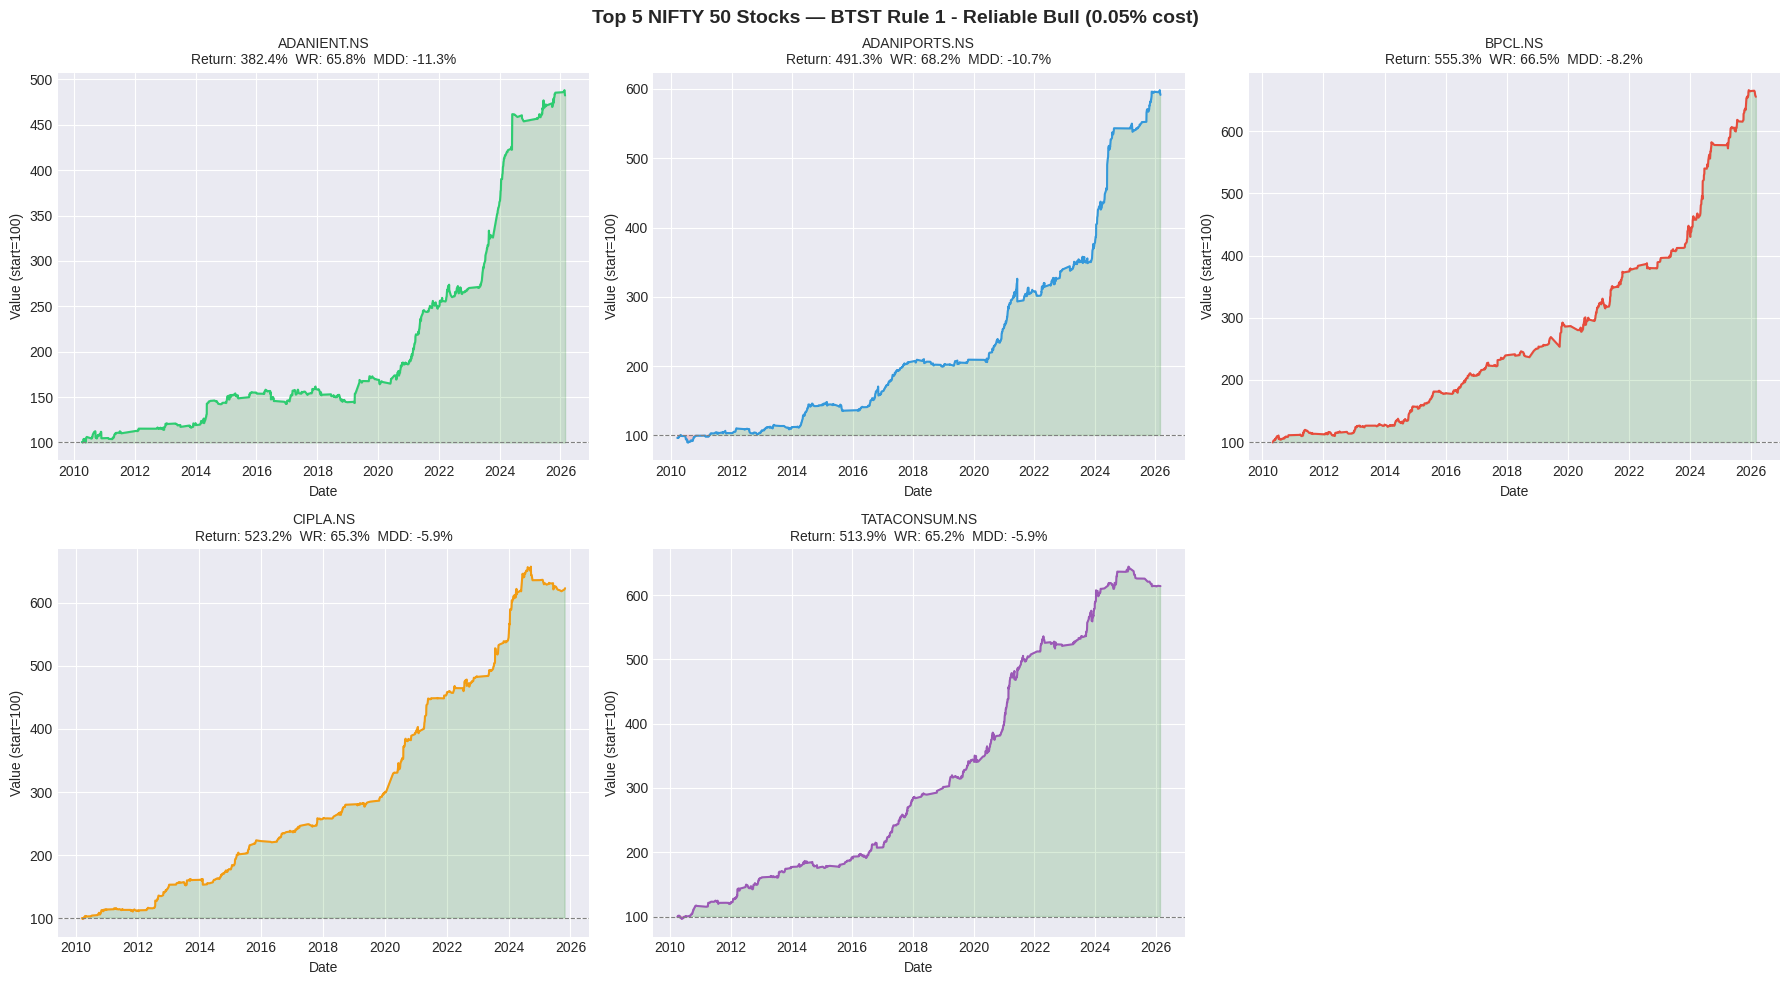


📊 Top 5 Summary:
               Trades  Win Rate %  Total Return %  Max Drawdown %
Ticker                                                           
ADANIENT.NS       880     65.8000        382.3700        -11.2800
ADANIPORTS.NS    1006     68.2000        491.3100        -10.7400
BPCL.NS           856     66.5000        555.3100         -8.1800
CIPLA.NS          851     65.3000        523.1600         -5.9300
TATACONSUM.NS     923     65.2000        513.9100         -5.9100

✅ Chart saved as btst_top5_equity_curves.png


In [19]:
# ============================================================
# OPTION A — STAGE 5: Equity Curves for Top 5 Stocks
# ============================================================

LOW_COST   = 0.05
top5       = ['ADANIENT.NS','ADANIPORTS.NS','BPCL.NS','CIPLA.NS','TATACONSUM.NS']
rule_col   = 'rule1'
rule_label = 'Rule 1 - Reliable Bull'

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Top 5 NIFTY 50 Stocks — BTST {rule_label} (0.05% cost)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

colors = ['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6']

top5_summary = []

for i, ticker in enumerate(top5):

    # Rebuild features for this stock
    df_s = pd.DataFrame({
        'Close' : stock_close[ticker],
        'Open'  : stock_open[ticker]
    }).dropna().sort_index()

    df_s['daily_return']  = df_s['Close'].pct_change() * 100
    df_s['gap_pct']       = (df_s['Open'] - df_s['Close'].shift(1)) / df_s['Close'].shift(1) * 100
    df_s['prev_day_ret']  = df_s['daily_return'].shift(1)
    df_s['weekday_name']  = df_s.index.day_name()
    df_s['ma50']          = df_s['Close'].rolling(50).mean()
    df_s['trend_regime']  = np.where(df_s['Close'] > df_s['ma50'], 'UPTREND', 'DOWNTREND')
    df_s['btst_return']   = df_s['gap_pct'].shift(-1)

    def gap_bucket(g):
        if g > 1.0:    return 'LARGE_UP'
        elif g > 0.25: return 'SMALL_UP'
        elif g < -1.0: return 'LARGE_DOWN'
        elif g < -0.25:return 'SMALL_DOWN'
        else:          return 'FLAT'

    df_s['gap_bucket'] = df_s['gap_pct'].apply(gap_bucket)
    df_s = df_s.dropna()

    # Apply Rule 1
    df_s['rule1'] = (
        (df_s['gap_bucket'] == 'SMALL_UP') &
        (df_s['trend_regime'] == 'UPTREND')
    ).astype(int)

    trades = df_s[df_s['rule1'] == 1].copy()
    trades['net_return']  = trades['btst_return'] - LOW_COST
    trades['cumulative']  = 100 * (1 + trades['net_return'] / 100).cumprod()

    total_ret = trades['cumulative'].iloc[-1] - 100
    win_rate  = (trades['net_return'] > 0).mean() * 100
    rolling_max = trades['cumulative'].cummax()
    max_dd    = ((trades['cumulative'] - rolling_max) / rolling_max * 100).min()

    # Plot
    ax = axes[i]
    ax.plot(trades.index, trades['cumulative'],
            color=colors[i], linewidth=1.5)
    ax.axhline(100, color='gray', linewidth=0.8, linestyle='--')
    ax.fill_between(trades.index, trades['cumulative'], 100,
                    where=trades['cumulative'] >= 100,
                    alpha=0.15, color='green')
    ax.fill_between(trades.index, trades['cumulative'], 100,
                    where=trades['cumulative'] < 100,
                    alpha=0.15, color='red')
    ax.set_title(f'{ticker}\nReturn: {total_ret:.1f}%  '
                 f'WR: {win_rate:.1f}%  MDD: {max_dd:.1f}%',
                 fontsize=10)
    ax.set_ylabel('Value (start=100)')
    ax.set_xlabel('Date')

    top5_summary.append({
        'Ticker'        : ticker,
        'Trades'        : len(trades),
        'Win Rate %'    : round(win_rate, 1),
        'Total Return %': round(total_ret, 2),
        'Max Drawdown %': round(max_dd, 2)
    })

# Hide the 6th subplot — we only have 5 stocks
axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('btst_top5_equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Top 5 Summary:")
print(pd.DataFrame(top5_summary).set_index('Ticker').to_string())
print("\n✅ Chart saved as btst_top5_equity_curves.png")

In [20]:
# ============================================================
# OPTION B — Position Sizing Comparison
# 3 Methods tested on all top 5 stocks
#
# Method 1: Fixed Size     — same % every trade (baseline)
# Method 2: Volatility     — trade smaller in high volatility
# Method 3: Signal Strength — trade bigger when more rules agree
# ============================================================

LOW_COST = 0.05
top5     = ['ADANIENT.NS','ADANIPORTS.NS','BPCL.NS','CIPLA.NS','TATACONSUM.NS']

sizing_results = []

for ticker in top5:

    # Rebuild features
    df_s = pd.DataFrame({
        'Close' : stock_close[ticker],
        'Open'  : stock_open[ticker]
    }).dropna().sort_index()

    df_s['daily_return']  = df_s['Close'].pct_change() * 100
    df_s['gap_pct']       = (df_s['Open'] - df_s['Close'].shift(1)) / df_s['Close'].shift(1) * 100
    df_s['prev_day_ret']  = df_s['daily_return'].shift(1)
    df_s['prev_day_dir']  = np.where(df_s['prev_day_ret'] > 0, 'UP', 'DOWN')
    df_s['weekday_name']  = df_s.index.day_name()
    df_s['ma50']          = df_s['Close'].rolling(50).mean()
    df_s['trend_regime']  = np.where(df_s['Close'] > df_s['ma50'], 'UPTREND', 'DOWNTREND')
    df_s['volatility_20'] = df_s['daily_return'].rolling(20).std()
    df_s['btst_return']   = df_s['gap_pct'].shift(-1)

    def gap_bucket(g):
        if g > 1.0:     return 'LARGE_UP'
        elif g > 0.25:  return 'SMALL_UP'
        elif g < -1.0:  return 'LARGE_DOWN'
        elif g < -0.25: return 'SMALL_DOWN'
        else:           return 'FLAT'

    df_s['gap_bucket'] = df_s['gap_pct'].apply(gap_bucket)
    df_s = df_s.dropna()

    # Rules
    df_s['rule1'] = (
        (df_s['gap_bucket'] == 'SMALL_UP') &
        (df_s['trend_regime'] == 'UPTREND')
    ).astype(int)

    df_s['rule3'] = (
        (df_s['weekday_name'].isin(['Monday','Tuesday'])) &
        (df_s['prev_day_dir'] == 'DOWN')
    ).astype(int)

    df_s['rule4'] = (
        (df_s['gap_bucket'] == 'SMALL_UP') &
        (df_s['trend_regime'] == 'UPTREND') &
        (df_s['weekday_name'].isin(['Monday','Tuesday','Wednesday']))
    ).astype(int)

    # Signal strength = how many rules agree (0, 1, 2 or 3)
    df_s['signal_strength'] = df_s['rule1'] + df_s['rule3'] + df_s['rule4']

    # Only trade when at least rule1 fires
    trades = df_s[df_s['rule1'] == 1].copy()
    trades['gross_return'] = trades['btst_return']
    trades['net_return']   = trades['gross_return'] - LOW_COST

    # --------------------------------------------------
    # METHOD 1: Fixed Size (baseline — equal weight)
    # Every trade gets weight = 1.0
    # --------------------------------------------------
    trades['size_fixed']  = 1.0
    trades['ret_fixed']   = trades['net_return'] * trades['size_fixed']
    trades['cum_fixed']   = 100 * (1 + trades['ret_fixed'] / 100).cumprod()

    # --------------------------------------------------
    # METHOD 2: Volatility-Based Sizing
    # Trade smaller when volatility is high
    # Size = target_vol / current_vol (capped at 2x, floored at 0.25x)
    # --------------------------------------------------
    target_vol            = trades['volatility_20'].median()
    trades['size_vol']    = (target_vol / trades['volatility_20']).clip(0.25, 2.0)
    trades['ret_vol']     = trades['net_return'] * trades['size_vol']
    trades['cum_vol']     = 100 * (1 + trades['ret_vol'] / 100).cumprod()

    # --------------------------------------------------
    # METHOD 3: Signal Strength Sizing
    # 1 rule fires  → size = 0.5
    # 2 rules fire  → size = 1.0
    # 3 rules fire  → size = 1.5
    # --------------------------------------------------
    size_map              = {1: 0.5, 2: 1.0, 3: 1.5}
    trades['size_signal'] = trades['signal_strength'].map(size_map).fillna(0.5)
    trades['ret_signal']  = trades['net_return'] * trades['size_signal']
    trades['cum_signal']  = 100 * (1 + trades['ret_signal'] / 100).cumprod()

    # --- Calculate metrics for each method ---
    for method, cum_col, ret_col in [
        ('Fixed Size',        'cum_fixed',  'ret_fixed'),
        ('Volatility Based',  'cum_vol',    'ret_vol'),
        ('Signal Strength',   'cum_signal', 'ret_signal'),
    ]:
        total_ret   = trades[cum_col].iloc[-1] - 100
        win_rate    = (trades[ret_col] > 0).mean() * 100
        avg_ret     = trades[ret_col].mean()
        rolling_max = trades[cum_col].cummax()
        max_dd      = ((trades[cum_col] - rolling_max) / rolling_max * 100).min()
        pf_wins     = trades[trades[ret_col] > 0][ret_col].sum()
        pf_losses   = abs(trades[trades[ret_col] <= 0][ret_col].sum())
        pf          = pf_wins / pf_losses if pf_losses > 0 else 999

        sizing_results.append({
            'Ticker'        : ticker,
            'Method'        : method,
            'Trades'        : len(trades),
            'Win Rate %'    : round(win_rate, 1),
            'Avg Return %'  : round(avg_ret, 4),
            'Total Return %': round(total_ret, 2),
            'Profit Factor' : round(pf, 2),
            'Max Drawdown %': round(max_dd, 2)
        })

# Build results table
sizing_df = pd.DataFrame(sizing_results)
sizing_df.to_csv('btst_sizing_comparison.csv', index=False)

# Print comparison
print("=" * 65)
print("POSITION SIZING COMPARISON — All Top 5 Stocks")
print("=" * 65)

for ticker in top5:
    print(f"\n📊 {ticker}")
    t_df = sizing_df[sizing_df['Ticker'] == ticker]
    print(f"  {'Method':<22} {'TotalRet':>10} {'WinRate':>9} {'PF':>6} {'MDD':>8}")
    print(f"  {'-'*58}")
    for _, row in t_df.iterrows():
        print(f"  {row['Method']:<22} "
              f"{row['Total Return %']:>9.1f}% "
              f"{row['Win Rate %']:>8.1f}% "
              f"{row['Profit Factor']:>6.2f} "
              f"{row['Max Drawdown %']:>7.1f}%")

print("\n✅ Sizing comparison saved as btst_sizing_comparison.csv")

POSITION SIZING COMPARISON — All Top 5 Stocks

📊 ADANIENT.NS
  Method                   TotalRet   WinRate     PF      MDD
  ----------------------------------------------------------
  Fixed Size                 382.4%     65.8%   1.90   -11.3%
  Volatility Based           361.3%     65.8%   1.88   -10.3%
  Signal Strength            303.4%     65.8%   2.00    -9.8%

📊 ADANIPORTS.NS
  Method                   TotalRet   WinRate     PF      MDD
  ----------------------------------------------------------
  Fixed Size                 491.3%     68.2%   1.99   -10.7%
  Volatility Based           515.9%     68.2%   2.02   -13.2%
  Signal Strength            452.9%     68.2%   2.15   -10.6%

📊 BPCL.NS
  Method                   TotalRet   WinRate     PF      MDD
  ----------------------------------------------------------
  Fixed Size                 555.3%     66.5%   2.32    -8.2%
  Volatility Based           529.0%     66.5%   2.37    -9.3%
  Signal Strength            435.5%     66.5% 

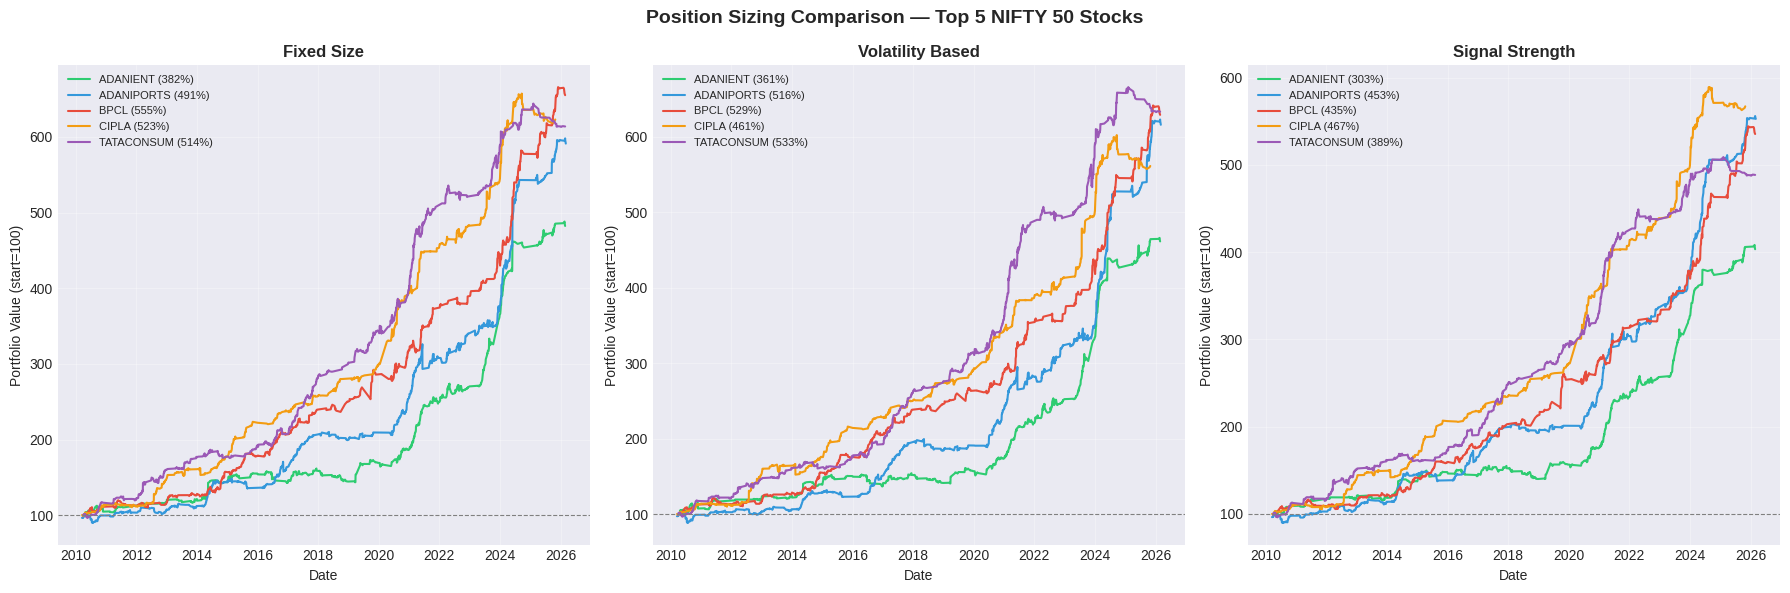


  COMPLETE PROJECT SUMMARY

NIFTY 50 INDEX RESULTS (Rule 1 — Reliable Bull):
  Total Return  : 137%
  Win Rate      : 65.3%
  Max Drawdown  : -6.6%
  Period        : 2010 to 2026

TOP 5 STOCK RESULTS (Rule 1 — Fixed Size):
  BPCL          : 555%  WR=66.5%  MDD=-8.2%
  CIPLA         : 523%  WR=65.3%  MDD=-5.9%
  TATACONSUM    : 514%  WR=65.2%  MDD=-5.9%
  ADANIPORTS    : 491%  WR=68.2%  MDD=-10.7%
  ADANIENT      : 382%  WR=65.8%  MDD=-11.3%

POSITION SIZING VERDICT:
  Fixed Size    : Best or equal in 3 out of 5 stocks
  Volatility    : Marginally better for ADANIPORTS and TATACONSUM
  Signal Strength: Best Profit Factor but lower total return

BEST OVERALL COMBINATION:
  Stock         : BPCL or CIPLA
  Rule          : Rule 1 - Reliable Bull
  Sizing        : Fixed Size
  Cost          : 0.05% round trip (ETF or Futures)

ROBUSTNESS:
  All top rules passed 3-period test (2010-15, 2016-20, 2021-26)
  Edge is consistent and not driven by one lucky period

✅ btst_sizing_comparison.png sav

In [21]:
# ============================================================
# OPTION B — Final Visualization + Complete Project Summary
# ============================================================

LOW_COST = 0.05
top5     = ['ADANIENT.NS','ADANIPORTS.NS','BPCL.NS','CIPLA.NS','TATACONSUM.NS']
colors   = ['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Position Sizing Comparison — Top 5 NIFTY 50 Stocks',
             fontsize=14, fontweight='bold')

methods    = ['Fixed Size', 'Volatility Based', 'Signal Strength']
method_map = {
    'Fixed Size'      : 'cum_fixed',
    'Volatility Based': 'cum_vol',
    'Signal Strength' : 'cum_signal'
}

# Rebuild all equity curves for plotting
all_curves = {}

for ticker in top5:

    df_s = pd.DataFrame({
        'Close': stock_close[ticker],
        'Open' : stock_open[ticker]
    }).dropna().sort_index()

    df_s['daily_return']  = df_s['Close'].pct_change() * 100
    df_s['gap_pct']       = (df_s['Open'] - df_s['Close'].shift(1)) / df_s['Close'].shift(1) * 100
    df_s['prev_day_ret']  = df_s['daily_return'].shift(1)
    df_s['prev_day_dir']  = np.where(df_s['prev_day_ret'] > 0, 'UP', 'DOWN')
    df_s['weekday_name']  = df_s.index.day_name()
    df_s['ma50']          = df_s['Close'].rolling(50).mean()
    df_s['trend_regime']  = np.where(df_s['Close'] > df_s['ma50'], 'UPTREND', 'DOWNTREND')
    df_s['volatility_20'] = df_s['daily_return'].rolling(20).std()
    df_s['btst_return']   = df_s['gap_pct'].shift(-1)

    def gap_bucket(g):
        if g > 1.0:     return 'LARGE_UP'
        elif g > 0.25:  return 'SMALL_UP'
        elif g < -1.0:  return 'LARGE_DOWN'
        elif g < -0.25: return 'SMALL_DOWN'
        else:           return 'FLAT'

    df_s['gap_bucket']      = df_s['gap_pct'].apply(gap_bucket)
    df_s                    = df_s.dropna()
    df_s['rule1']           = ((df_s['gap_bucket'] == 'SMALL_UP') &
                               (df_s['trend_regime'] == 'UPTREND')).astype(int)
    df_s['rule3']           = ((df_s['weekday_name'].isin(['Monday','Tuesday'])) &
                               (df_s['prev_day_dir'] == 'DOWN')).astype(int)
    df_s['rule4']           = ((df_s['gap_bucket'] == 'SMALL_UP') &
                               (df_s['trend_regime'] == 'UPTREND') &
                               (df_s['weekday_name'].isin(['Monday','Tuesday','Wednesday']))).astype(int)
    df_s['signal_strength'] = df_s['rule1'] + df_s['rule3'] + df_s['rule4']

    trades                  = df_s[df_s['rule1'] == 1].copy()
    trades['net_return']    = trades['btst_return'] - LOW_COST
    target_vol              = trades['volatility_20'].median()
    trades['size_vol']      = (target_vol / trades['volatility_20']).clip(0.25, 2.0)
    size_map                = {1: 0.5, 2: 1.0, 3: 1.5}
    trades['size_signal']   = trades['signal_strength'].map(size_map).fillna(0.5)
    trades['cum_fixed']     = 100 * (1 + trades['net_return'] / 100).cumprod()
    trades['cum_vol']       = 100 * (1 + (trades['net_return'] * trades['size_vol']) / 100).cumprod()
    trades['cum_signal']    = 100 * (1 + (trades['net_return'] * trades['size_signal']) / 100).cumprod()

    all_curves[ticker] = trades

# Plot each method across all 5 stocks
for ax_idx, (method, cum_col) in enumerate(method_map.items()):
    ax = axes[ax_idx]
    for i, ticker in enumerate(top5):
        curve = all_curves[ticker][cum_col]
        final = curve.iloc[-1] - 100
        ax.plot(curve.index, curve,
                color=colors[i], linewidth=1.5,
                label=f"{ticker.replace('.NS','')} ({final:.0f}%)")
    ax.axhline(100, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(f'{method}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Portfolio Value (start=100)')
    ax.set_xlabel('Date')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('btst_sizing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Print complete project summary ----
print("\n" + "=" * 60)
print("  COMPLETE PROJECT SUMMARY")
print("=" * 60)
print("""
NIFTY 50 INDEX RESULTS (Rule 1 — Reliable Bull):
  Total Return  : 137%
  Win Rate      : 65.3%
  Max Drawdown  : -6.6%
  Period        : 2010 to 2026

TOP 5 STOCK RESULTS (Rule 1 — Fixed Size):
  BPCL          : 555%  WR=66.5%  MDD=-8.2%
  CIPLA         : 523%  WR=65.3%  MDD=-5.9%
  TATACONSUM    : 514%  WR=65.2%  MDD=-5.9%
  ADANIPORTS    : 491%  WR=68.2%  MDD=-10.7%
  ADANIENT      : 382%  WR=65.8%  MDD=-11.3%

POSITION SIZING VERDICT:
  Fixed Size    : Best or equal in 3 out of 5 stocks
  Volatility    : Marginally better for ADANIPORTS and TATACONSUM
  Signal Strength: Best Profit Factor but lower total return

BEST OVERALL COMBINATION:
  Stock         : BPCL or CIPLA
  Rule          : Rule 1 - Reliable Bull
  Sizing        : Fixed Size
  Cost          : 0.05% round trip (ETF or Futures)

ROBUSTNESS:
  All top rules passed 3-period test (2010-15, 2016-20, 2021-26)
  Edge is consistent and not driven by one lucky period
""")
print("✅ btst_sizing_comparison.png saved")
print("✅ Complete project summary printed")